In [92]:
import pandas as pd

In [93]:
df = pd.read_csv('16_air_quality_prediction.csv')

In [94]:
df.shape

(1460, 6)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1460 non-null   object 
 1   location       1460 non-null   object 
 2   pm2.5          1460 non-null   float64
 3   pm10           1460 non-null   float64
 4   temperature    1460 non-null   float64
 5   predicted_aqi  1460 non-null   float64
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [96]:
df.head()

,date,location,pm2.5,pm10,temperature,predicted_aqi
0,2023-01-01,Istanbul,29.05,58.73,15.4,40.71
1,2023-01-01,Ankara,24.74,83.86,26.4,50.63
2,2023-01-01,Izmir,23.90,76.91,27.8,39.67
3,2023-01-01,Bursa,43.67,49.58,30.6,36.50
4,2023-01-02,Istanbul,28.40,76.31,23.9,46.89


In [97]:
df['location'].unique()

array(['Istanbul', 'Ankara', 'Izmir', 'Bursa'], dtype=object)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1460 non-null   object 
 1   location       1460 non-null   object 
 2   pm2.5          1460 non-null   float64
 3   pm10           1460 non-null   float64
 4   temperature    1460 non-null   float64
 5   predicted_aqi  1460 non-null   float64
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [99]:
df.isnull().sum()

date             0
location         0
pm2.5            0
pm10             0
temperature      0
predicted_aqi    0
dtype: int64

In [100]:
df.describe()

,pm2.5,pm10,temperature,predicted_aqi
count,1460.00000,1460.000000,1460.000000,1460.000000
mean,35.06900,69.815788,20.006644,44.493281
std,10.08376,19.665744,8.826885,9.543069
min,2.94000,-0.190000,5.100000,15.000000
25%,28.59750,56.887500,12.000000,38.045000
50%,35.23000,70.025000,19.850000,44.765000
75%,41.59500,82.572500,27.800000,50.825000
max,67.08000,142.220000,35.000000,78.930000


In [101]:
df.head()

,date,location,pm2.5,pm10,temperature,predicted_aqi
0,2023-01-01,Istanbul,29.05,58.73,15.4,40.71
1,2023-01-01,Ankara,24.74,83.86,26.4,50.63
2,2023-01-01,Izmir,23.90,76.91,27.8,39.67
3,2023-01-01,Bursa,43.67,49.58,30.6,36.50
4,2023-01-02,Istanbul,28.40,76.31,23.9,46.89


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1460 non-null   object 
 1   location       1460 non-null   object 
 2   pm2.5          1460 non-null   float64
 3   pm10           1460 non-null   float64
 4   temperature    1460 non-null   float64
 5   predicted_aqi  1460 non-null   float64
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


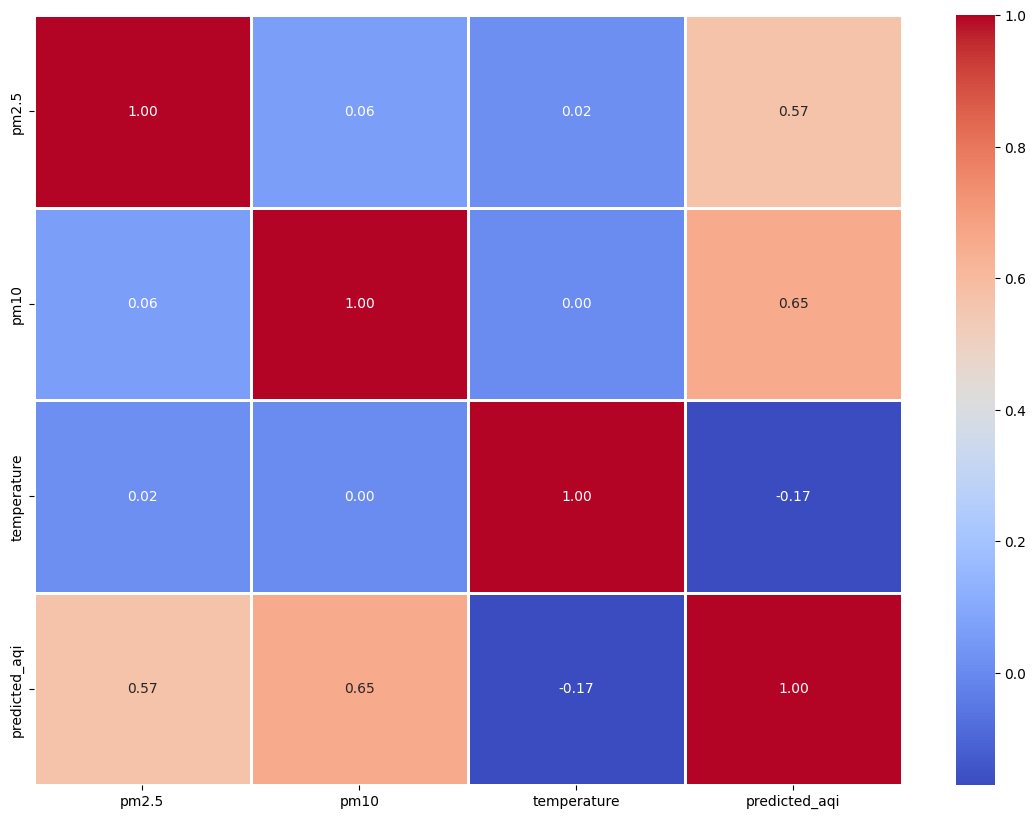

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=1)
plt.show()

In [104]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df['month'] = df['date'].dt.month


train = df[df['month'] <= 9]
test = df[df['month'] > 9]

X_train = train.drop(['predicted_aqi', 'date'], axis=1)
X_test = test.drop(['predicted_aqi', 'date'], axis=1)

y_train = train['predicted_aqi']
y_test = test['predicted_aqi']

In [105]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

scale_col = X_train.select_dtypes(include=[float, int]).columns

cat_col = X_train.select_dtypes(include=[object]).columns



preprocessor = ColumnTransformer(transformers=[
    ('ss', StandardScaler(), scale_col ),
    ('encode', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_col)
], remainder='passthrough')


In [106]:
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

In [107]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_pre,y_train)
y_pred = lr.predict(X_test_pre)
y_pred_train = lr.predict(X_train_pre)

print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))
print('--test--')
print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))


train
4.818527370345549
23.218206018769195
3.873611176404054
0.7416762818861482
--test--
5.10990871178061
26.111167042731378
4.078071670667478
0.7224813645559693


In [108]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor()

param = [{
    'n_estimators':[50,100,150,200],
    'max_depth':[2,3,4],
    'min_samples_leaf':[3,4,5,6]
}]
grid = GridSearchCV(estimator=rf, param_grid=param, n_jobs=-1, cv=5)
grid.fit(X_train_pre,y_train)
y_pred = grid.predict(X_test_pre)
y_pred_train = grid.predict(X_train_pre)

print(grid.best_params_)
print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))
print('--test--')
print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))


{'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 150}
train
4.912572727986273
24.133370807754492
3.912216875913003
0.7314942389330255
--test--
5.787359893417225
33.49353453593423
4.627015543346426
0.644018975276041


In [109]:
from sklearn.neighbors import KNeighborsRegressor


knn = KNeighborsRegressor(n_neighbors=3, n_jobs=-1)

knn.fit(X_train_pre,y_train)
y_pred = knn.predict(X_test_pre)
y_pred_train = knn.predict(X_train_pre)

print(grid.best_params_)
print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))
print('--test--')
print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))


{'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 150}
train
4.2699901121185935
18.232815557590555
3.4100518925518926
0.7971432976900361
--test--
6.443768056760242
41.52214676932367
5.110045289855073
0.5586880703849199
